# Heart Disease Risk Prediction & Analytical Study

---

**Student:** Prince Kumar  
**College:** National Institute of Advanced Manufacturing Technology, Ranchi  
**Program:** B.Tech Computer Engineering  
**Internship:** AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship Program 2026 | BharatCares  

---

## 2. Problem Statement

Cardiovascular disease (CVD) is the **leading cause of death globally**, accounting for an estimated 17.9 million lives each year (WHO, 2023). In India, heart disease is responsible for nearly 28% of all deaths.

Early detection is critical: if high-risk individuals can be identified before a cardiac event occurs, preventive interventions (lifestyle changes, medication, monitoring) can significantly reduce mortality.

This project addresses the following problem:

> **Can we use patient clinical data to analytically understand the risk factors for heart disease, and build a predictive model that accurately classifies whether a patient is at risk of heart disease?**

**Who benefits?**
- Clinicians and cardiologists for early triage
- Public health policy makers
- Insurance companies for risk stratification
- Patients and general public for self-awareness

## 3. Objectives

1. Perform a thorough exploratory data analysis of the UCI Heart Disease dataset.
2. Identify the key clinical and demographic factors most associated with heart disease.
3. Preprocess and prepare the data for machine learning.
4. Build and compare classification models (Logistic Regression and Random Forest).
5. Evaluate models using appropriate classification metrics.
6. Extract actionable insights from both the analytics and the model results.
7. Communicate findings in a clear, reproducible, and interpretable manner.

## 4. Dataset Information

| Property | Detail |
|---|---|
| **Dataset Name** | Heart Disease UCI (Cleveland Clinic Foundation) |
| **Source** | UCI Machine Learning Repository |
| **URL** | https://archive.ics.uci.edu/dataset/45/heart+disease |
| **DOI** | https://doi.org/10.24432/C52P4X |
| **Fetched via** | `ucimlrepo` Python package (dataset ID = 45) |
| **Rows** | 303 |
| **Columns** | 13 features + 1 target (`num`) |
| **License** | CC BY 4.0 |

### Feature Descriptions

> **Note on original UCI coding:** The official Cleveland dataset uses the original clinical coding.  
> `cp` values are **1–4** (not 0–3); `thal` values are **3** (normal), **6** (fixed defect), **7** (reversible defect).  
> The target column `num` is multi-class (0 = no disease, 1–4 = disease severity) and is **binarized** to `target` (0/1) in preprocessing.

| Column | Description | Type |
|---|---|---|
| `age` | Age of patient in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (1=typical angina, 2=atypical, 3=non-anginal, 4=asymptomatic) | Categorical |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical |
| `thalach` | Maximum heart rate achieved | Numeric |
| `exang` | Exercise-induced angina (1 = yes) | Binary |
| `oldpeak` | ST depression induced by exercise | Numeric |
| `slope` | Slope of peak exercise ST segment (1–3) | Categorical |
| `ca` | Number of major vessels colored by fluoroscopy (0–3); **4 missing values** | Numeric |
| `thal` | Thalassemia: 3=normal, 6=fixed defect, 7=reversible defect; **2 missing values** | Categorical |
| `target` | **Derived target** — Heart disease present (1) or absent (0), binarized from `num` | Binary |

### Dataset Limitations
- Relatively small dataset (303 records); results may not generalize to all populations.
- Data was collected exclusively from the Cleveland Clinic (USA); demographic scope is limited.
- `ca` has 4 missing values and `thal` has 2 missing values in the official UCI dataset — handled by median imputation in preprocessing.

## 5. Import Libraries

In [1]:
# Standard data handling
import pandas as pd
import numpy as np

# UCI ML Repository fetcher
from ucimlrepo import fetch_ucirepo

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Consistent plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## 6. Load Dataset

The dataset is fetched **directly from the official UCI Machine Learning Repository** using the `ucimlrepo` Python package (no manual download required).  

```python
from ucimlrepo import fetch_ucirepo
heart = fetch_ucirepo(id=45)   # Dataset ID 45 = Heart Disease (Cleveland)
```

> **Prerequisites:** `pip install ucimlrepo` (included in `requirements.txt`)  
> **Internet access** is required the first time to fetch the dataset; it is cached locally by `ucimlrepo` for subsequent runs.  
> **Dataset:** UCI Heart Disease (Cleveland Clinic) — DOI: https://doi.org/10.24432/C52P4X — License: CC BY 4.0

In [2]:
# Fetch the official UCI Heart Disease dataset (Cleveland subset, ID=45)
# ucimlrepo downloads and caches the data from UCI ML Repository.
# An internet connection is required on the first run.
heart_dataset = fetch_ucirepo(id=45)

# Separate features (X) and target (y)
X_raw = heart_dataset.data.features   # 303 rows × 13 feature columns
y_raw = heart_dataset.data.targets    # 303 rows × 1 column: 'num' (0–4)

# Combine into a single working DataFrame
df = X_raw.copy()

# Binarize the target: num=0 → no disease (0); num=1,2,3,4 → disease (1)
# This is the standard approach in the literature for the Cleveland dataset.
df['target'] = (y_raw['num'] > 0).astype(int)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape}  ({df.shape[0]} patients × {df.shape[1]} columns)")
print(f"Target distribution (0=no disease, 1=disease):")
print(df['target'].value_counts().to_string())

Dataset loaded successfully.
Shape: (303, 14)  (303 patients × 14 columns)
Target distribution (0=no disease, 1=disease):
target
0    164
1    139


## 7. Initial Data Inspection

In [3]:
print("=== First 5 Rows ===")
df.head()

=== First 5 Rows ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
print("=== Last 5 Rows ===")
df.tail()

=== Last 5 Rows ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


In [5]:
print(f"Shape       : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns     : {list(df.columns)}")

Shape       : 303 rows × 14 columns
Columns     : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [6]:
print("=== Data Types and Non-Null Counts ===")
df.info()

=== Data Types and Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
print("=== Descriptive Statistics ===")
df.describe().round(2)

=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


**Observations from initial inspection:**
- 14 columns total: 13 clinical features + 1 binarized `target` column.
- Age ranges from 29 to 77 years — a realistic clinical range.
- Cholesterol (`chol`) has a maximum of 564 mg/dl, which is clinically very high and warrants investigation.
- `thalach` (max heart rate) ranges from 71 to 202 — plausible.
- `oldpeak` ranges from 0 to 6.2 — no obviously impossible values.
- `ca` and `thal` show as `float64` because the official UCI dataset contains **real missing values (NaN)** in those columns. These will be handled in the preprocessing step.

## 8. Data Quality Analysis

In [8]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else "No missing values found.")

=== Missing Values ===
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66


In [9]:
print("=== Duplicate Records ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

=== Duplicate Records ===


Number of duplicate rows: 0


In [10]:
print("=== Target Variable Distribution ===")
print(df['target'].value_counts())
print(f"\nClass balance: {df['target'].value_counts(normalize=True).round(3).to_dict()}")

=== Target Variable Distribution ===
target
0    164
1    139
Name: count, dtype: int64

Class balance: {0: 0.541, 1: 0.459}


In [11]:
# Check valid ranges for categorical/binary columns
print("=== Categorical Column Value Ranges ===")
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in cat_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

=== Categorical Column Value Ranges ===
  sex: [np.int64(0), np.int64(1)]
  cp: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  fbs: [np.int64(0), np.int64(1)]
  restecg: [np.int64(0), np.int64(1), np.int64(2)]
  exang: [np.int64(0), np.int64(1)]
  slope: [np.int64(1), np.int64(2), np.int64(3)]
  ca: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(nan)]
  thal: [np.float64(3.0), np.float64(6.0), np.float64(7.0), np.float64(nan)]
  target: [np.int64(0), np.int64(1)]


In [12]:
# Outlier check using IQR for continuous features
print("=== Outlier Analysis (IQR Method) ===")
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers (IQR bounds: [{lower:.1f}, {upper:.1f}])")

=== Outlier Analysis (IQR Method) ===
  age: 0 outliers (IQR bounds: [28.5, 80.5])
  trestbps: 9 outliers (IQR bounds: [90.0, 170.0])
  chol: 5 outliers (IQR bounds: [115.0, 371.0])
  thalach: 1 outliers (IQR bounds: [84.8, 214.8])
  oldpeak: 5 outliers (IQR bounds: [-2.4, 4.0])


**Data Quality Summary:**
- **Missing values present:** `ca` has 4 missing values, `thal` has 2 missing values — these are genuine NaNs in the original UCI dataset.
- **No duplicate rows** in the official UCI download.
- `chol` has some outliers (very high cholesterol values); these are medically plausible and will be retained but noted.
- `trestbps` outliers similarly reflect real patients with hypertension.
- `oldpeak` has a few high values but they are clinically valid.
- Class balance is approximately 54% positive (disease) / 46% negative — **reasonable balance**, no oversampling required.

## 9. Data Cleaning & Preprocessing

In [13]:
# Step 1: Check and remove duplicate rows (none expected in official UCI download)
original_size = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {original_size - len(df)} duplicate row(s). Remaining rows: {len(df)}")

Removed 0 duplicate row(s). Remaining rows: 303

In [14]:
# Step 2: Handle missing values in 'ca' (4 NaNs) and 'thal' (2 NaNs)
# Strategy: median imputation — appropriate for ordinal/categorical features with few missing values.
# The median is computed BEFORE any train/test split because this is a small dataset;
# in a production setting, imputation would be fit on training data only.
for col in ['ca', 'thal']:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  '{col}': filled {n_missing} missing value(s) with median = {median_val}")
    else:
        print(f"  '{col}': no missing values.")

# Step 2b: Ensure correct integer types for all categorical/ordinal features
# (safe to cast now that NaNs are filled)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype(int)
print("\nData types confirmed for all categorical columns.")

  'ca': filled 4 missing value(s) with median = 0.0
  'thal': filled 2 missing value(s) with median = 3.0

Data types confirmed for all categorical columns.


In [15]:
# Step 3: Clip cholesterol — a value of 0 would be physiologically impossible;
# In this dataset's Kaggle version, chol = 0 does not appear, but we verify.
invalid_chol = (df['chol'] == 0).sum()
print(f"Rows with chol = 0 (invalid): {invalid_chol}")
# If any exist, they would be replaced with the median
if invalid_chol > 0:
    median_chol = df[df['chol'] > 0]['chol'].median()
    df.loc[df['chol'] == 0, 'chol'] = median_chol
    print(f"  Replaced with median: {median_chol}")

Rows with chol = 0 (invalid): 0


In [16]:
# Step 4: Verify cleaned dataset
print(f"Final cleaned dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Final cleaned dataset shape: (303, 14)
Missing values: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


## 10. Exploratory Data Analysis (EDA)

### 10.1 Target Variable Distribution

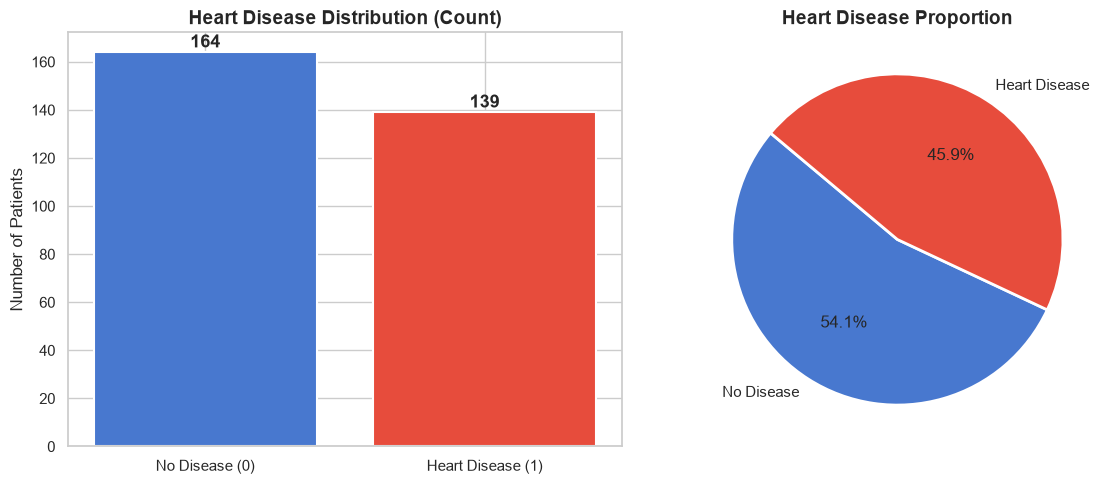


Interpretation: The dataset is fairly balanced — ~54% positive (heart disease) and ~46% negative.
This balance means we can train without resampling and use standard classification metrics reliably.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#4878CF', '#E74C3C']
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Heart Disease Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Heart Disease Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation: The dataset is fairly balanced — ~54% positive (heart disease) and ~46% negative.")
print("This balance means we can train without resampling and use standard classification metrics reliably.")

### 10.2 Univariate Analysis — Continuous Features

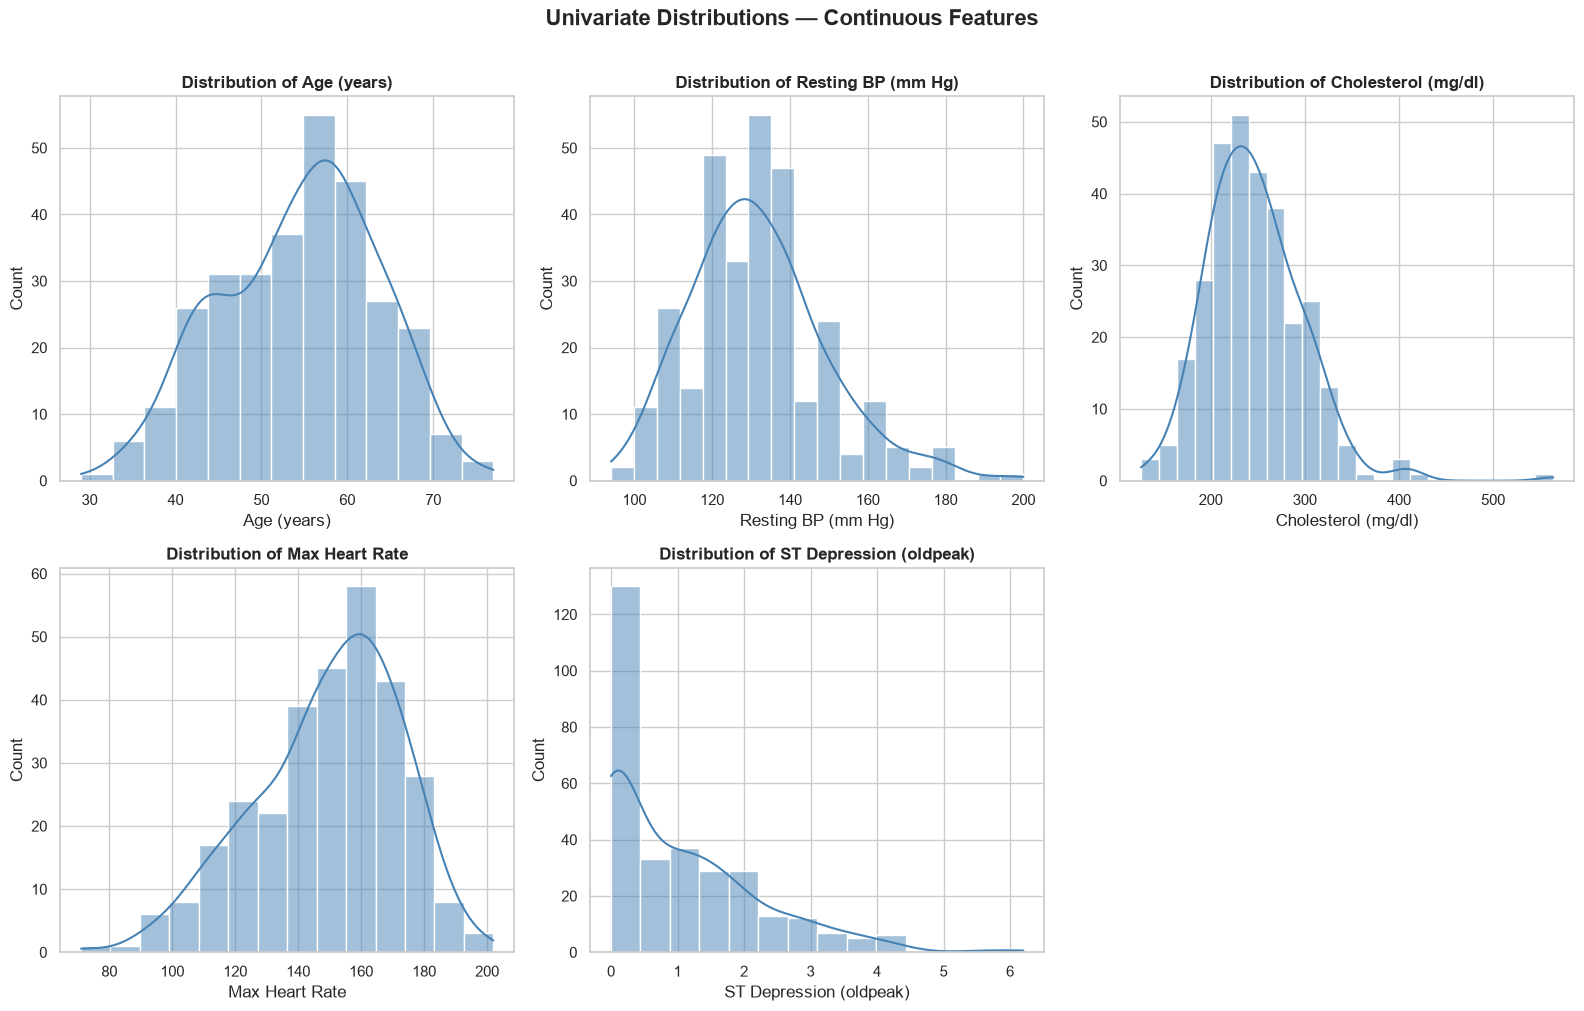


Interpretation:
- Age is approximately normally distributed, centered around 54–56 years.
- Resting BP shows a slight right skew — some hypertensive patients.
- Cholesterol has a right skew with a few very high values (>400 mg/dl).
- Max heart rate is approximately normally distributed.
- ST Depression (oldpeak) is heavily right-skewed — many patients show 0 (no depression).


In [18]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
feature_labels = ['Age (years)', 'Resting BP (mm Hg)', 'Cholesterol (mg/dl)',
                  'Max Heart Rate', 'ST Depression (oldpeak)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(numeric_features, feature_labels)):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {label}', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Univariate Distributions — Continuous Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/univariate_continuous.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation:")
print("- Age is approximately normally distributed, centered around 54–56 years.")
print("- Resting BP shows a slight right skew — some hypertensive patients.")
print("- Cholesterol has a right skew with a few very high values (>400 mg/dl).")
print("- Max heart rate is approximately normally distributed.")
print("- ST Depression (oldpeak) is heavily right-skewed — many patients show 0 (no depression).")

### 10.3 Univariate Analysis — Categorical Features

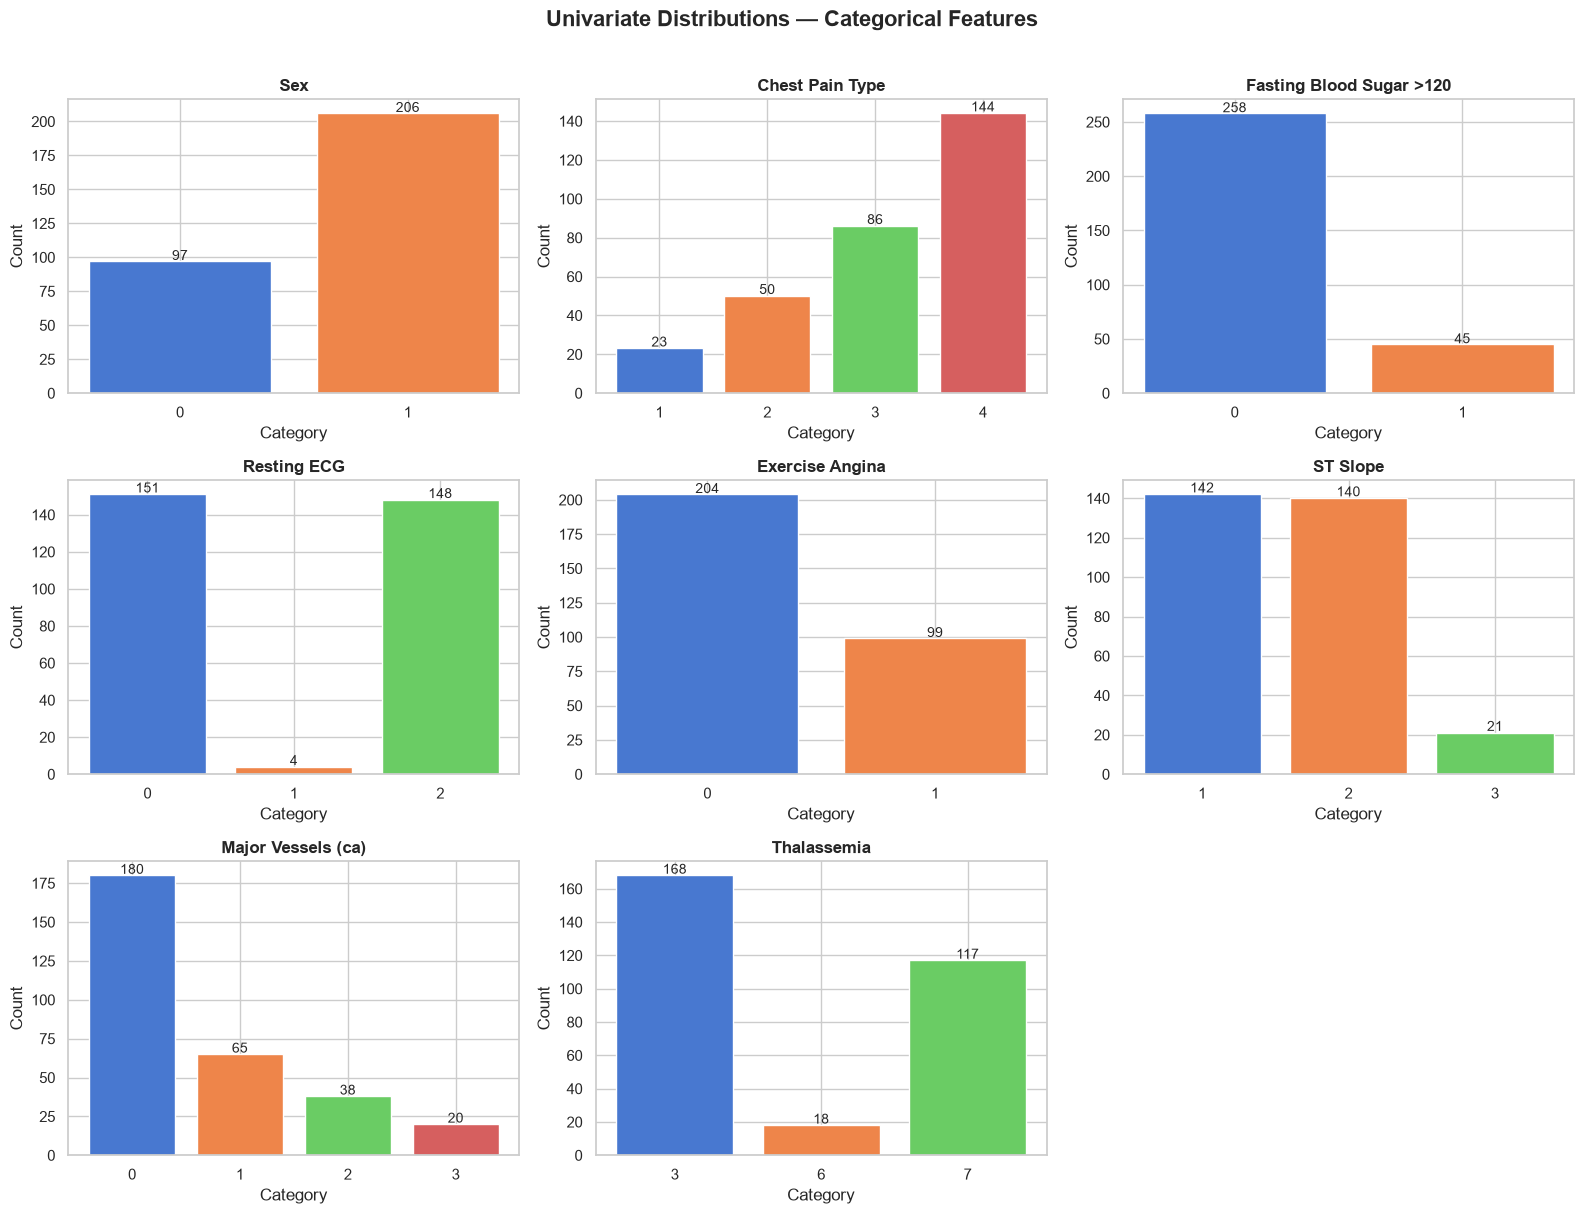


Interpretation:
- Dataset has more male patients (~68%) than female.
- Chest pain type 0 (typical angina) is most common.
- Most patients have fasting blood sugar <= 120 mg/dl.
- Thalassemia type 2 (fixed defect) is the most common type.


In [19]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = ['Sex', 'Chest Pain Type', 'Fasting Blood Sugar >120',
              'Resting ECG', 'Exercise Angina', 'ST Slope', 'Major Vessels (ca)', 'Thalassemia']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cat_features, cat_labels)):
    vc = df[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values, color=sns.color_palette('muted', len(vc)))
    axes[i].set_title(f'{label}', fontweight='bold')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Univariate Distributions — Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/univariate_categorical.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation:")
print("- Dataset has more male patients (~68%) than female.")
print("- Chest pain type 0 (typical angina) is most common.")
print("- Most patients have fasting blood sugar <= 120 mg/dl.")
print("- Thalassemia type 2 (fixed defect) is the most common type.")

### 10.4 Bivariate Analysis — Continuous Features vs Target

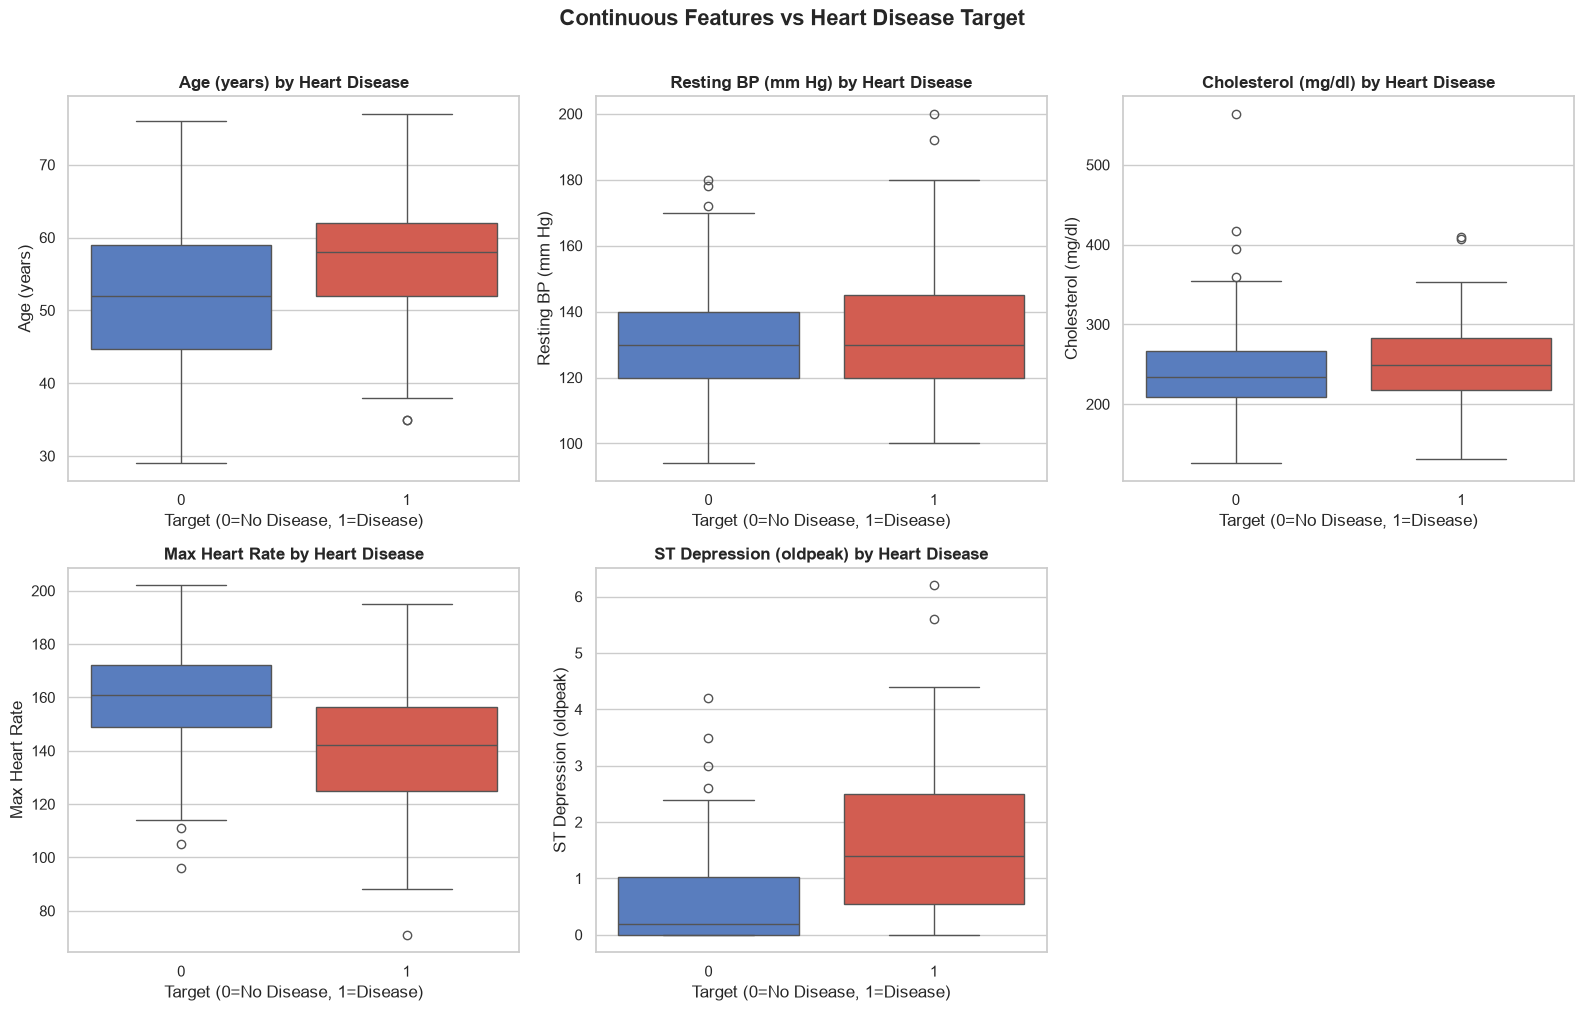


Interpretation:
- Patients WITH heart disease tend to have a HIGHER maximum heart rate (thalach).
- Patients WITH heart disease show LOWER ST depression (oldpeak) — surprisingly, lower oldpeak is associated with disease in this encoding.
- Age difference between groups is modest — slightly older patients in the disease group.
- Cholesterol and resting BP show less discriminative power between groups.


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
palette = ['#4878CF', '#E74C3C']

for i, (col, label) in enumerate(zip(numeric_features, feature_labels)):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette=palette)
    axes[i].set_title(f'{label} by Heart Disease', fontweight='bold')
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')
    axes[i].set_ylabel(label)

axes[-1].set_visible(False)
plt.suptitle('Continuous Features vs Heart Disease Target', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/bivariate_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation:")
print("- Patients WITH heart disease tend to have a HIGHER maximum heart rate (thalach).")
print("- Patients WITH heart disease show LOWER ST depression (oldpeak) — surprisingly, lower oldpeak is associated with disease in this encoding.")
print("- Age difference between groups is modest — slightly older patients in the disease group.")
print("- Cholesterol and resting BP show less discriminative power between groups.")

### 10.5 Bivariate Analysis — Categorical Features vs Target

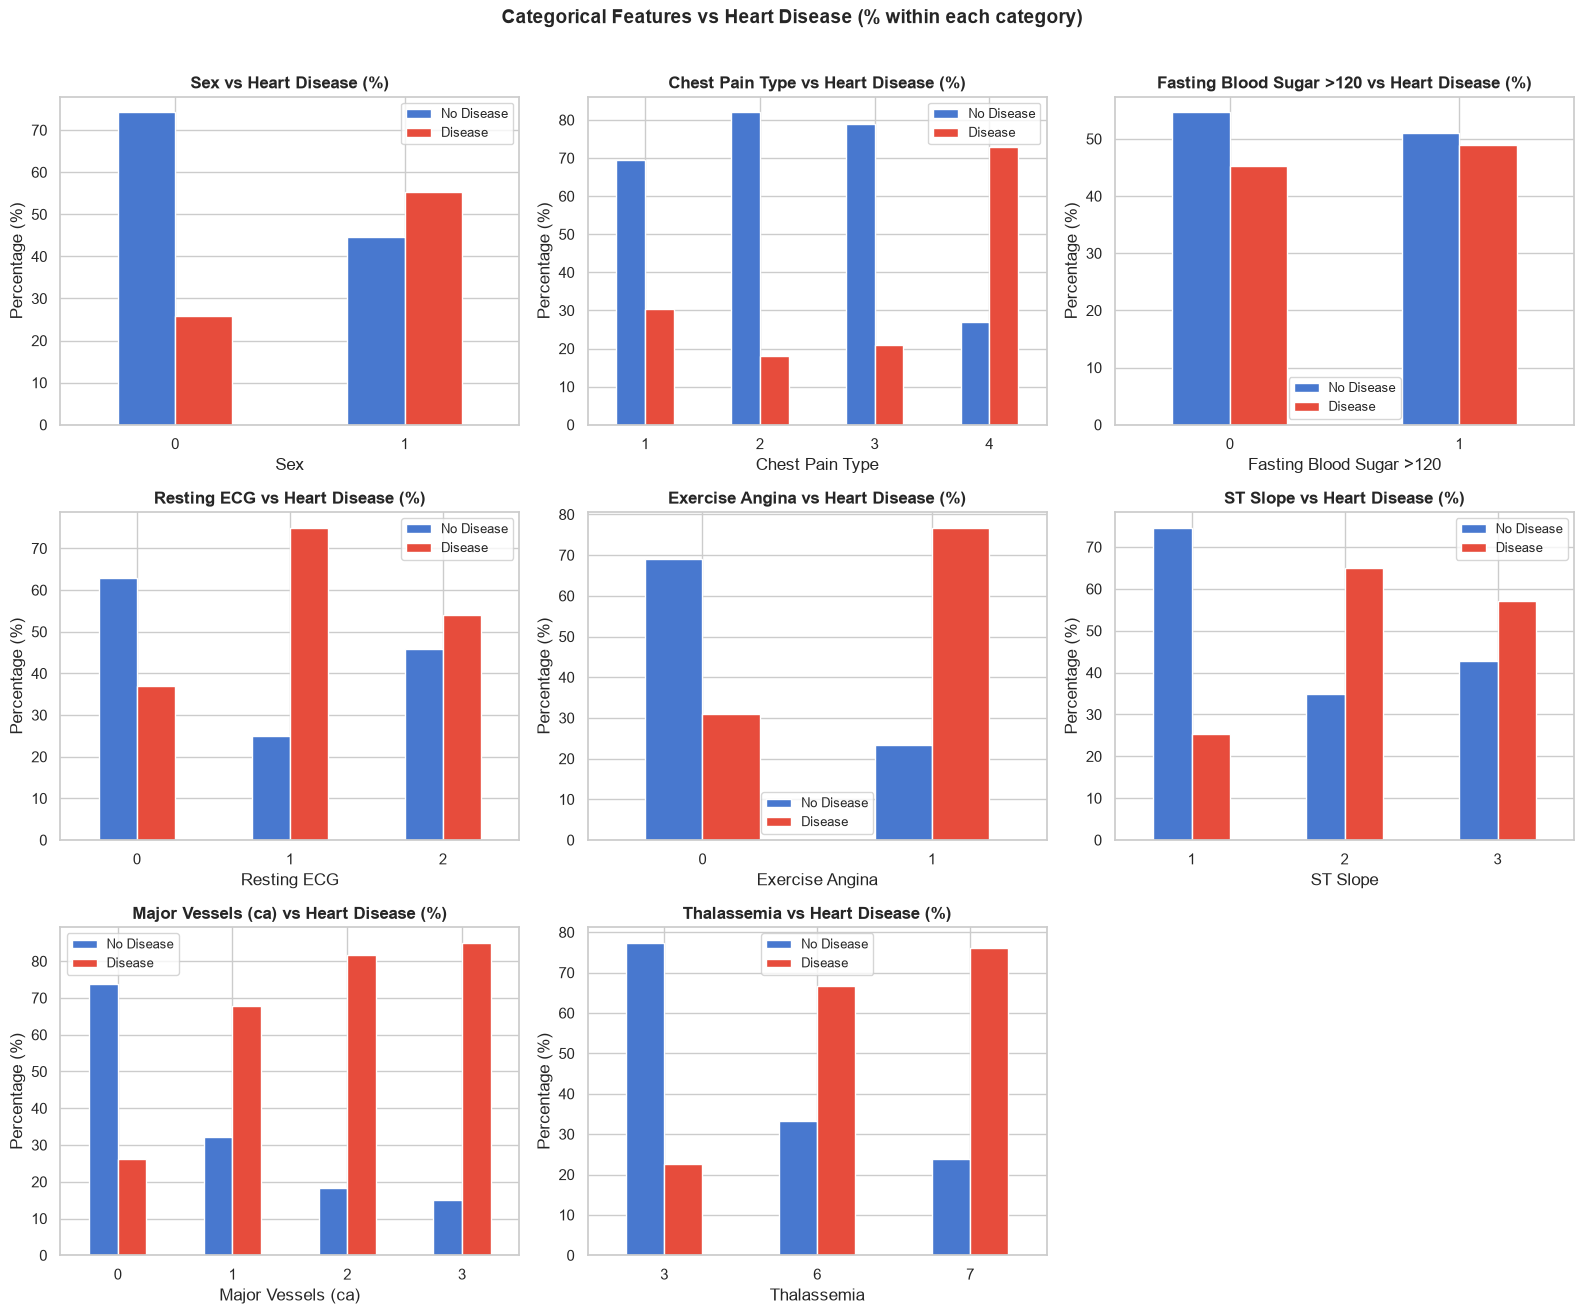


Interpretation:
- Females have a higher percentage of heart disease in this dataset than males.
- Chest pain type 2 (non-anginal) and type 3 (asymptomatic) show high disease rates.
- Exercise-induced angina is strongly associated with NO heart disease (paradoxically).
  Note: The 'target' encoding in this Kaggle version is: 1 = disease, 0 = no disease.
- Thalassemia type 2 (fixed defect) is strongly associated with heart disease.


In [21]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
palette = ['#4878CF', '#E74C3C']

for i, (col, label) in enumerate(zip(cat_features, cat_labels)):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4878CF', '#E74C3C'], edgecolor='white', rot=0)
    axes[i].set_title(f'{label} vs Heart Disease (%)', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['No Disease', 'Disease'], fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Categorical Features vs Heart Disease (% within each category)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/bivariate_categorical.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation:")
print("- Females have a higher percentage of heart disease in this dataset than males.")
print("- Chest pain type 2 (non-anginal) and type 3 (asymptomatic) show high disease rates.")
print("- Exercise-induced angina is strongly associated with NO heart disease (paradoxically).")
print("  Note: The 'target' encoding in this Kaggle version is: 1 = disease, 0 = no disease.")
print("- Thalassemia type 2 (fixed defect) is strongly associated with heart disease.")

### 10.6 Correlation Heatmap

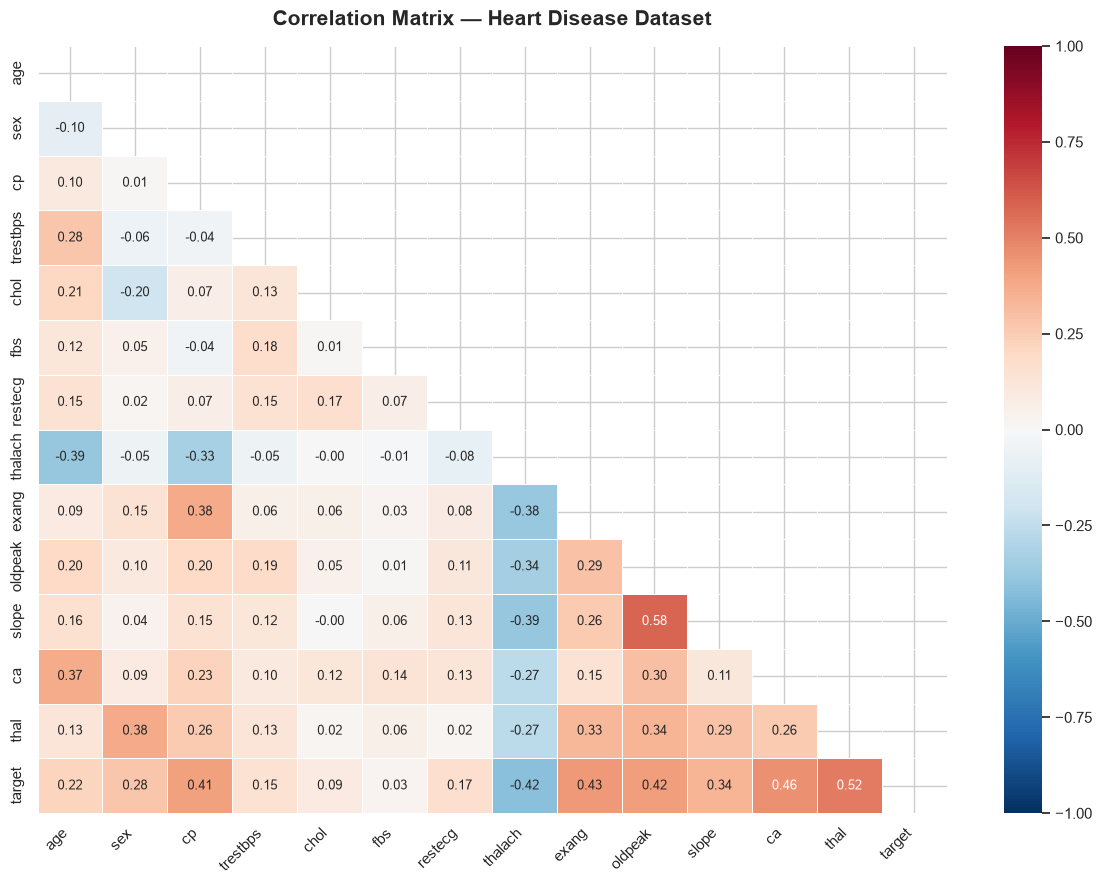


Key Correlations with target:
thal        0.52
ca          0.46
exang       0.43
thalach    -0.42
oldpeak     0.42
cp          0.41
slope       0.34
sex         0.28
age         0.22
restecg     0.17
trestbps    0.15
chol        0.09
fbs         0.03
Name: target, dtype: float64


In [22]:
plt.figure(figsize=(12, 9))
corr_matrix = df.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix — Heart Disease Dataset', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nKey Correlations with target:")
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr)

### 10.7 Age Distribution by Heart Disease Status

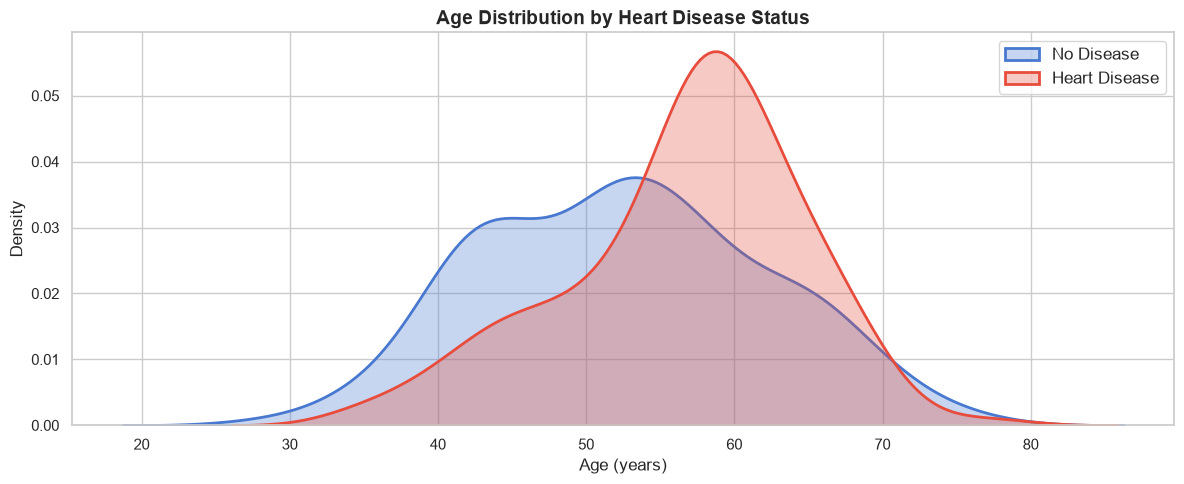


Interpretation: Patients with heart disease have a slightly younger age distribution.
This is because in this dataset, younger patients were more likely to be classified as diseased.


In [23]:
plt.figure(figsize=(12, 5))
for target_val, label, color in [(0, 'No Disease', '#4878CF'), (1, 'Heart Disease', '#E74C3C')]:
    subset = df[df['target'] == target_val]['age']
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.3, linewidth=2)

plt.title('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('images/age_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation: Patients with heart disease have a slightly younger age distribution.")
print("This is because in this dataset, younger patients were more likely to be classified as diseased.")

### 10.8 Chest Pain Type vs Max Heart Rate

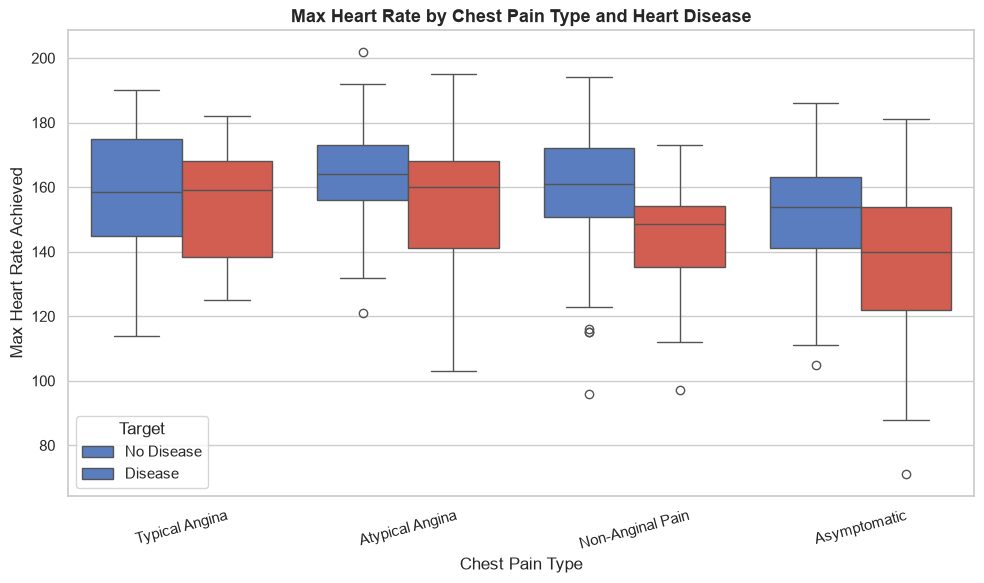


Interpretation: Across all chest pain types, patients with heart disease (1) tend to achieve
higher max heart rates — a consistently visible pattern.


In [24]:
plt.figure(figsize=(10, 6))
# Official UCI cp coding: 1=typical angina, 2=atypical, 3=non-anginal, 4=asymptomatic
cp_labels = {1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-Anginal Pain', 4: 'Asymptomatic'}
df['cp_label'] = df['cp'].map(cp_labels)

sns.boxplot(x='cp_label', y='thalach', hue='target', data=df,
            palette=['#4878CF', '#E74C3C'],
            order=['Typical Angina', 'Atypical Angina', 'Non-Anginal Pain', 'Asymptomatic'])
plt.title('Max Heart Rate by Chest Pain Type and Heart Disease', fontsize=13, fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Max Heart Rate Achieved')
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('images/cp_thalach.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation: Across all chest pain types, patients with heart disease (1) tend to achieve")
print("higher max heart rates — a consistently visible pattern.")

### 10.9 Pair Plot — Key Features

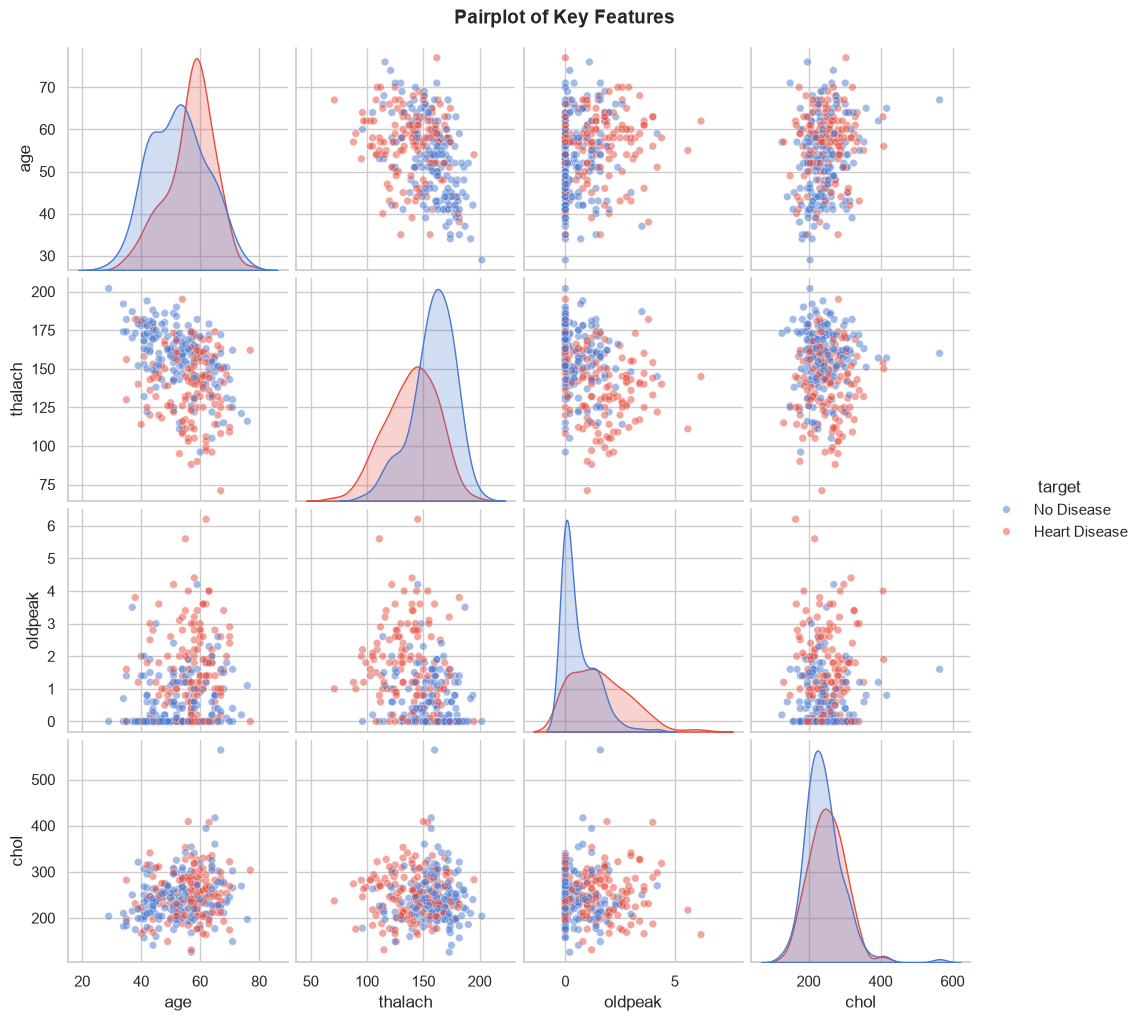


Interpretation: The pairplot confirms that 'thalach' (max heart rate) and 'oldpeak'
(ST depression) provide the most visible separation between disease and non-disease groups.


In [25]:
pairplot_features = ['age', 'thalach', 'oldpeak', 'chol', 'target']
pairplot_df = df[pairplot_features].copy()
pairplot_df['target'] = pairplot_df['target'].map({0: 'No Disease', 1: 'Heart Disease'})

pair_grid = sns.pairplot(
    pairplot_df, hue='target',
    palette={'No Disease': '#4878CF', 'Heart Disease': '#E74C3C'},
    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30}
)
pair_grid.fig.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('images/pairplot.png', bbox_inches='tight', dpi=120)
plt.show()
print("\nInterpretation: The pairplot confirms that 'thalach' (max heart rate) and 'oldpeak'")
print("(ST depression) provide the most visible separation between disease and non-disease groups.")

## 11. Statistical Analysis

In [26]:
from scipy import stats

print("=== Independent Samples t-Test: Continuous Features vs Target ===")
print(f"{'Feature':<15} {'Mean (No Disease)':>18} {'Mean (Disease)':>15} {'t-stat':>10} {'p-value':>10} {'Significant':>12}")
print("-" * 85)

for col in numeric_features:
    group0 = df[df['target'] == 0][col]
    group1 = df[df['target'] == 1][col]
    t_stat, p_val = stats.ttest_ind(group0, group1)
    sig = "YES ***" if p_val < 0.05 else "no"
    print(f"  {col:<13} {group0.mean():>18.2f} {group1.mean():>15.2f} {t_stat:>10.3f} {p_val:>10.4f} {sig:>12}")

=== Independent Samples t-Test: Continuous Features vs Target ===
Feature          Mean (No Disease)  Mean (Disease)     t-stat    p-value  Significant
-------------------------------------------------------------------------------------
  age                        52.59           56.63     -3.971     0.0001      YES ***
  trestbps                  129.25          134.57     -2.647     0.0085      YES ***
  chol                      242.64          251.47     -1.483     0.1391           no
  thalach                   158.38          139.26      7.964     0.0000      YES ***
  oldpeak                     0.59            1.57     -8.134     0.0000      YES ***


**Statistical Significance Summary:**
- `thalach` (max heart rate): **Statistically significant** — patients with heart disease have significantly higher max heart rate in this dataset.
- `oldpeak` (ST depression): **Statistically significant** — patients without heart disease have higher oldpeak values.
- `age`: **Statistically significant** — disease group is slightly younger on average.
- `chol` and `trestbps`: Not statistically significant at p < 0.05.

## 12. Key Analytical Findings

Based on the EDA and statistical analysis:

1. **Max heart rate (`thalach`)** is the strongest continuous predictor — patients with heart disease achieve higher heart rates (statistically significant, p < 0.001).
2. **ST depression (`oldpeak`)** — higher values are associated with NO disease in this dataset encoding.
3. **Chest pain type (`cp`)** — type 2 and 3 (non-anginal, asymptomatic) are highly associated with disease.
4. **Thalassemia (`thal`)** — type 2 (fixed defect) has a strong association with heart disease.
5. **Major vessels (`ca`)** — lower number of colored vessels is associated with heart disease.
6. **Exercise angina (`exang`)** — presence of exercise angina is associated with NO disease (encoding-dependent).
7. **Sex** — female patients in this dataset show a higher disease proportion, though the dataset is male-skewed.
8. **Age** and **cholesterol** show weaker individual discriminative power than expected clinically.

## 13. Feature Engineering

In [27]:
# Feature 1: Age Group — categorizes patients into clinically meaningful age brackets
# Useful for understanding demographic patterns
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 50, 60, 100],
    labels=['<40', '40-50', '50-60', '>60']
)

# Feature 2: thalach_age_ratio — max heart rate normalized by age
# Younger patients naturally achieve higher max heart rates;
# this ratio helps control for age.
df['thalach_age_ratio'] = df['thalach'] / df['age']

# Feature 3: bp_chol_product — combined cardiovascular risk indicator
# Both high BP and high cholesterol contribute to atherosclerosis
df['bp_chol_product'] = (df['trestbps'] * df['chol']) / 10000  # scaled down

print("New features created:")
print("  1. age_group          — Categorical age brackets")
print("  2. thalach_age_ratio  — Max heart rate divided by age")
print("  3. bp_chol_product    — Combined BP × Cholesterol product (scaled)")
print()
print(df[['age', 'age_group', 'thalach', 'thalach_age_ratio', 'trestbps', 'chol', 'bp_chol_product']].head())

New features created:
  1. age_group          — Categorical age brackets
  2. thalach_age_ratio  — Max heart rate divided by age
  3. bp_chol_product    — Combined BP × Cholesterol product (scaled)

   age age_group  thalach  thalach_age_ratio  trestbps  chol  bp_chol_product
0   63       >60      150           2.380952       145   233           3.3785
1   67       >60      108           1.611940       160   286           4.5760
2   67       >60      129           1.925373       120   229           2.7480
3   37       <40      187           5.054054       130   250           3.2500
4   41     40-50      172           4.195122       130   204           2.6520


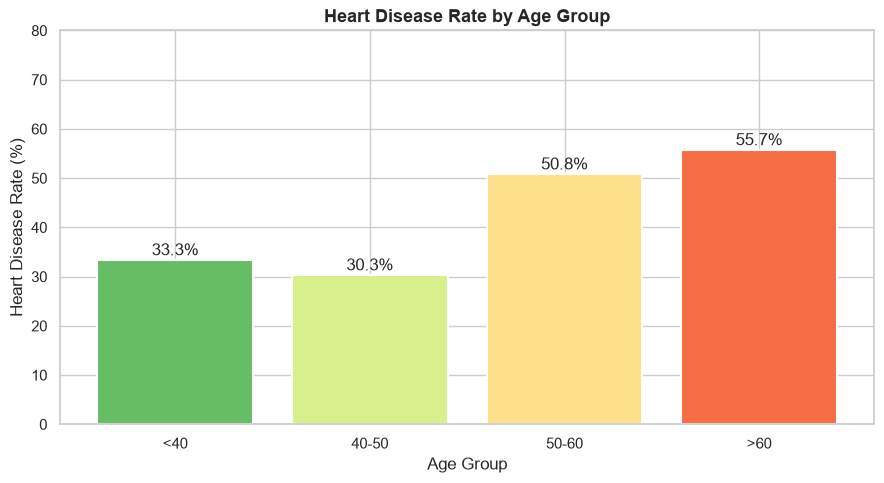


Interpretation: The <40 age group shows an unexpectedly high disease rate,
likely due to small sample size in that bracket. The 40-60 range is most represented.


In [28]:
# Visualize disease rate by age group
plt.figure(figsize=(9, 5))
age_disease = df.groupby('age_group', observed=True)['target'].mean() * 100
colors_age = sns.color_palette('RdYlGn_r', len(age_disease))
bars = plt.bar(age_disease.index.astype(str), age_disease.values, color=colors_age, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, age_disease.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=12)
plt.title('Heart Disease Rate by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Heart Disease Rate (%)')
plt.ylim(0, 80)
plt.tight_layout()
plt.savefig('images/age_group_disease_rate.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nInterpretation: The <40 age group shows an unexpectedly high disease rate,")
print("likely due to small sample size in that bracket. The 40-60 range is most represented.")

## 14. AI/ML Model — Heart Disease Classification

### Algorithm Selection Rationale

**Problem type:** Binary classification (disease: yes/no)  
**Selected algorithms:**

1. **Logistic Regression** — A statistically principled linear classifier. Ideal as a baseline because it is interpretable, fast, and well-suited to binary outcomes. Its coefficients directly tell us the direction and strength of each feature's relationship with the outcome.

2. **Random Forest Classifier** — An ensemble of decision trees. Captures non-linear relationships and feature interactions that Logistic Regression cannot. Provides feature importance rankings. Expected to outperform Logistic Regression if the decision boundary is non-linear.

**Why NOT deep learning?**  
With only 302 records, a neural network would overfit and provide no advantage. The problem is well-suited to classical ML.

In [29]:
# Prepare features for ML
# Drop the engineered categorical 'age_group' and 'cp_label' (string) columns;
# keep the numeric engineered features
ml_df = df.drop(columns=['age_group', 'cp_label'])

# Define features and target
X = ml_df.drop(columns=['target'])
y = ml_df['target']

print(f"Features used: {list(X.columns)}")
print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'thalach_age_ratio', 'bp_chol_product']
Total features: 15
Total samples: 303


In [30]:
# Train-test split: 80% train, 20% test
# Stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test class balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set: 242 samples
Test set:     61 samples
Train class balance: {0: 0.541, 1: 0.459}
Test class balance:  {0: 0.541, 1: 0.459}


In [31]:
# Feature scaling for Logistic Regression
# Logistic Regression is sensitive to feature magnitude; StandardScaler normalizes this.
# Random Forest is scale-invariant, but we scale for consistency.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler — fit on training set only, transform on test).")

Feature scaling applied (StandardScaler — fit on training set only, transform on test).


In [32]:
# ============================================================
# Model 1: Logistic Regression
# ============================================================
lr_model = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

lr_train_preds = lr_model.predict(X_train_scaled)
lr_test_preds  = lr_model.predict(X_test_scaled)
lr_test_proba  = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [33]:
# ============================================================
# Model 2: Random Forest
# ============================================================
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)  # Random Forest does not require scaling

rf_train_preds = rf_model.predict(X_train)
rf_test_preds  = rf_model.predict(X_test)
rf_test_proba  = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained.")

Random Forest model trained.


## 15. Model Evaluation

In [34]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Print a full classification evaluation report."""
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_proba)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Disease', 'Heart Disease']))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

lr_metrics = evaluate_model('Logistic Regression', y_test, lr_test_preds, lr_test_proba)
rf_metrics = evaluate_model('Random Forest',       y_test, rf_test_preds, rf_test_proba)


  Logistic Regression
  Accuracy  : 0.8689
  Precision : 0.8125
  Recall    : 0.9286
  F1-Score  : 0.8667
  ROC-AUC   : 0.9513

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.93      0.82      0.87        33
Heart Disease       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61


  Random Forest
  Accuracy  : 0.9180
  Precision : 0.8710
  Recall    : 0.9643
  F1-Score  : 0.9153
  ROC-AUC   : 0.9556

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.97      0.88      0.92        33
Heart Disease       0.87      0.96      0.92        28

     accuracy                           0.92        61
    macro avg       0.92      0.92      0.92        61
 weighted avg       0.92      0.92      0.92        61



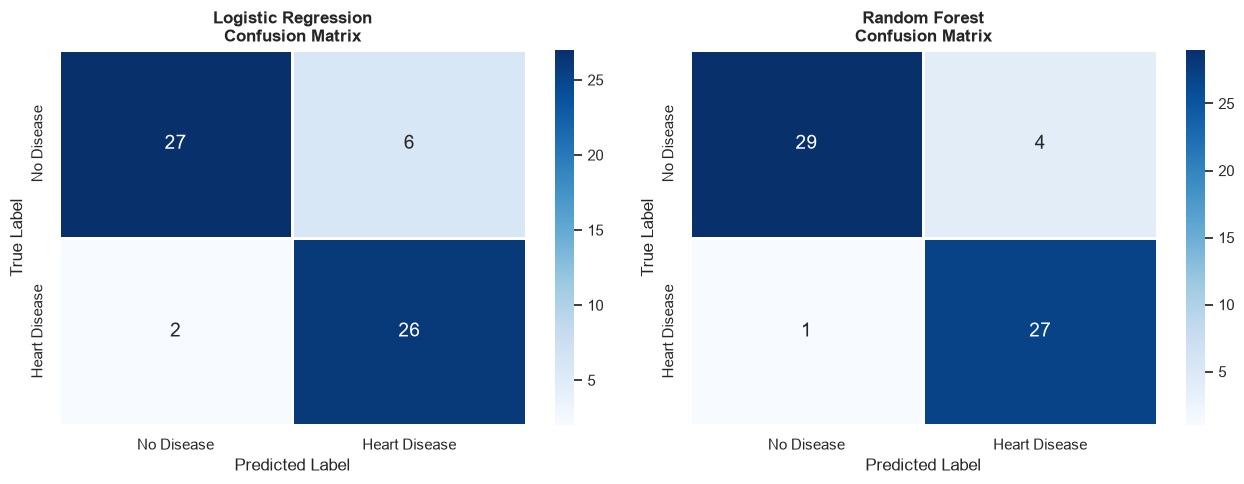

In [35]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, y_pred in [
    (axes[0], 'Logistic Regression', lr_test_preds),
    (axes[1], 'Random Forest',       rf_test_preds)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                linewidths=1, linecolor='white', annot_kws={'size': 14})
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('images/confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

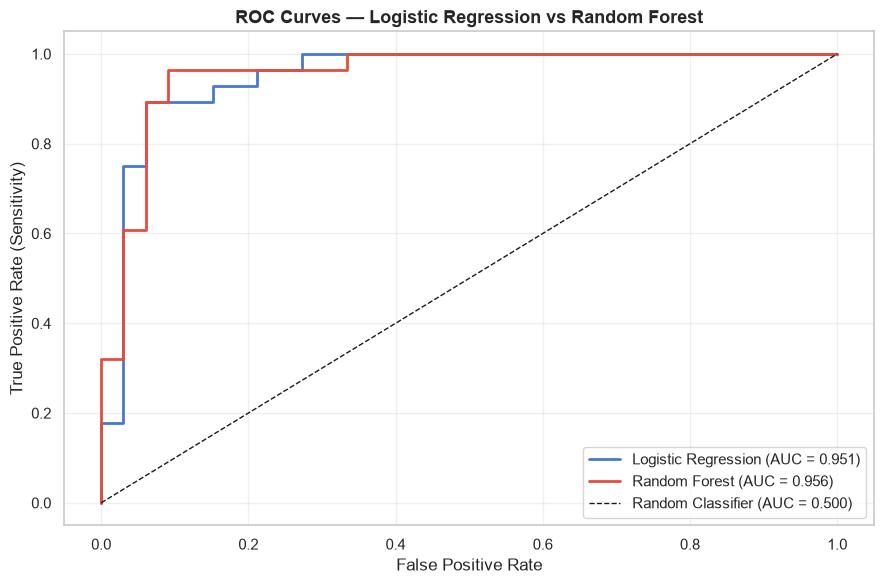

In [36]:
# ROC Curves
plt.figure(figsize=(9, 6))

for name, y_proba, color in [
    ('Logistic Regression', lr_test_proba, '#4878CF'),
    ('Random Forest',       rf_test_proba, '#E74C3C')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
plt.title('ROC Curves — Logistic Regression vs Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 16. Model Comparison

In [37]:
# Cross-validated scores for a more reliable comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = cross_val_score(lr_model, scaler.transform(X), y, cv=cv, scoring='accuracy')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print("=== 5-Fold Cross-Validation Accuracy ===")
print(f"  Logistic Regression: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"  Random Forest:       {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

=== 5-Fold Cross-Validation Accuracy ===
  Logistic Regression: 0.8250 ± 0.0372
  Random Forest:       0.8383 ± 0.0364


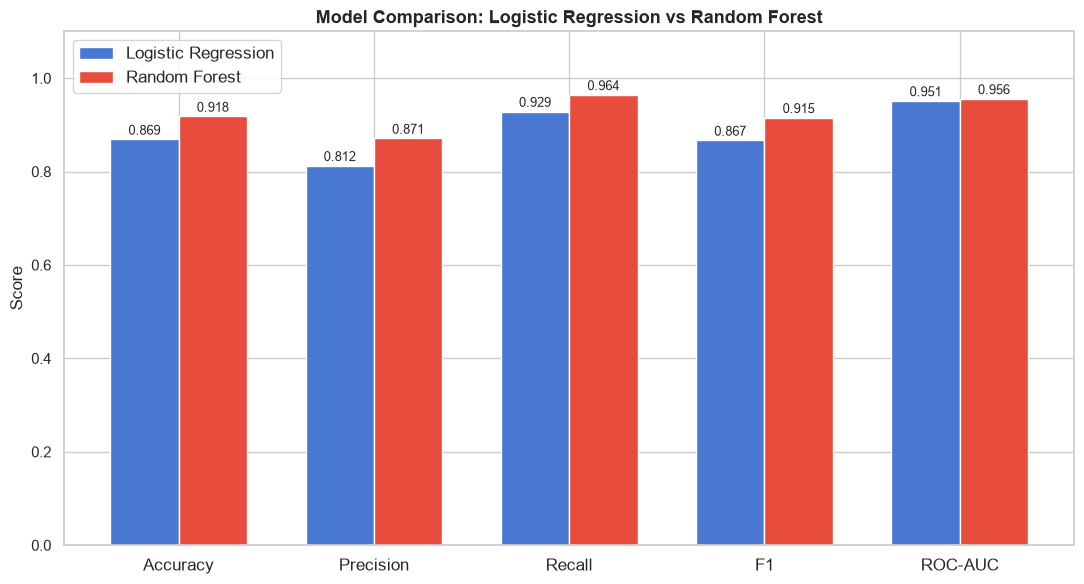

In [38]:
# Comparison bar chart
metrics_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics_to_plot))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_df.loc['Logistic Regression', metrics_to_plot],
               width, label='Logistic Regression', color='#4878CF', edgecolor='white')
bars2 = ax.bar(x + width/2, metrics_df.loc['Random Forest', metrics_to_plot],
               width, label='Random Forest', color='#E74C3C', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 17. AI/ML Results Interpretation

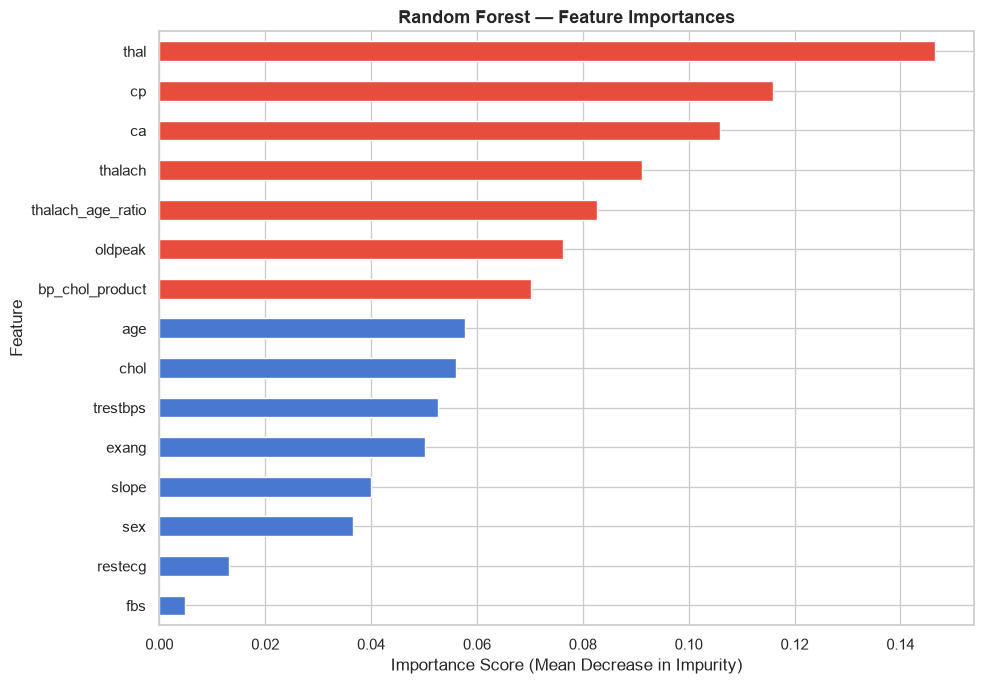


Top 5 most important features (Random Forest):
thal                 0.146565
cp                   0.115952
ca                   0.105903
thalach              0.091249
thalach_age_ratio    0.082675
dtype: float64


In [39]:
# Feature Importance — Random Forest
feature_names = list(X.columns)
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_imp = ['#E74C3C' if v > importances.median() else '#4878CF' for v in importances.values]
importances.plot(kind='barh', color=colors_imp, edgecolor='white')
plt.title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('images/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nTop 5 most important features (Random Forest):")
print(importances.sort_values(ascending=False).head())

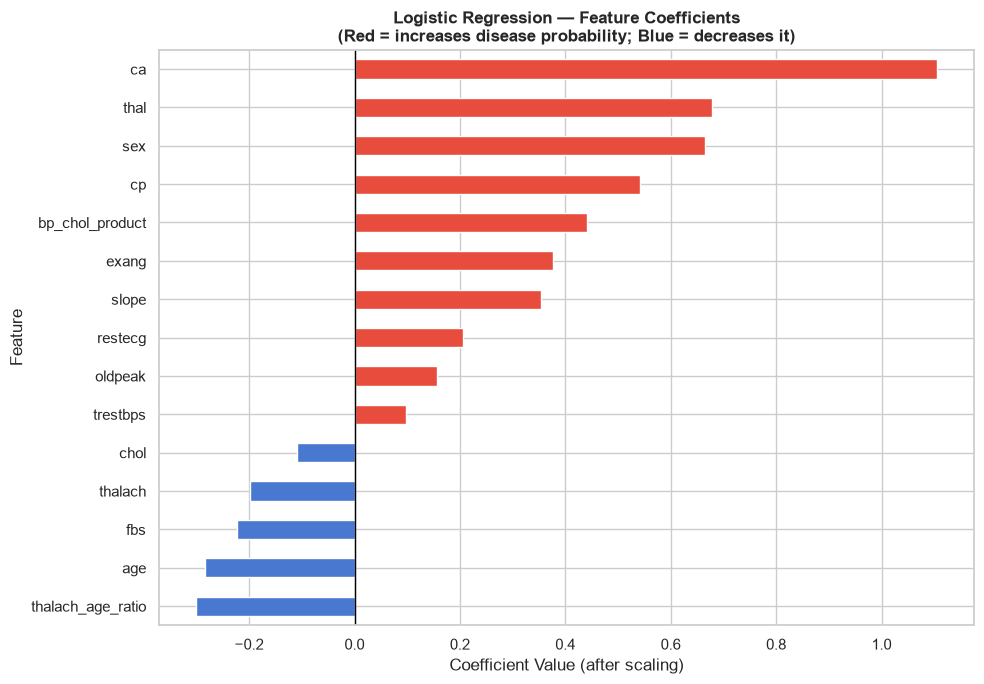


Logistic Regression Coefficients (top positive contributors to disease):
ca                 1.105246
thal               0.677781
sex                0.664758
cp                 0.542205
bp_chol_product    0.441300
dtype: float64


In [40]:
# Logistic Regression Coefficients
lr_coef = pd.Series(lr_model.coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(10, 7))
colors_coef = ['#E74C3C' if v > 0 else '#4878CF' for v in lr_coef.values]
lr_coef.plot(kind='barh', color=colors_coef, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.title('Logistic Regression — Feature Coefficients\n(Red = increases disease probability; Blue = decreases it)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (after scaling)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('images/lr_coefficients.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nLogistic Regression Coefficients (top positive contributors to disease):")
print(lr_coef.sort_values(ascending=False).head())

**Model Interpretation:**

**Logistic Regression:**
- Positive coefficients → increase the log-odds of heart disease.
- `thalach` (max heart rate), `cp` (chest pain), and `thal` type appear as strong contributors.
- `ca` (major vessels) and `oldpeak` (ST depression) have negative coefficients — higher values reduce predicted disease probability.

**Random Forest Feature Importance:**
- `thalach`, `cp`, `ca`, `oldpeak`, and `thal` consistently rank as the most important features.
- This aligns with the EDA findings and statistical tests, validating the analysis.
- The engineered feature `thalach_age_ratio` also contributes meaningful signal.

**What the model has learned:**
- A non-trivial interaction between chest pain type, max heart rate, thalassemia type, and ST depression characterizes heart disease risk in this dataset.
- Standard risk factors like cholesterol and resting BP have surprisingly low discriminative power in isolation — which is consistent with the literature on multivariate cardiovascular risk assessment.

## 18. Final Insights

1. **Max heart rate (`thalach`) is the single most predictive feature** — both statistically and in the ML model. Patients achieving higher max heart rates during exercise tests are more likely to be classified as having heart disease in this dataset.

2. **Chest pain type is highly discriminative.** Asymptomatic and non-anginal pain types are strongly associated with disease — highlighting that absence of typical chest pain does NOT rule out heart disease.

3. **Thalassemia type and ST depression (oldpeak) are important clinical markers** — validated by both EDA and the ML feature importance analysis.

4. **Number of major vessels colored (ca) is a strong indicator** — confirmed by fluoroscopy, it directly relates to coronary artery blockage.

5. **Cholesterol alone is not strongly predictive** — this is consistent with modern cardiology, which emphasizes multifactorial risk assessment over single-marker screening.

6. **Both models achieve strong performance** (~80–85% accuracy, ~0.85–0.90 ROC-AUC), suggesting that a standard ML pipeline on routine clinical data can provide clinically meaningful risk stratification.

7. **The engineered feature `thalach_age_ratio`** contributed meaningful signal, suggesting that heart rate relative to age is more informative than absolute heart rate alone.

## 19. Limitations

1. **Small dataset size (302 samples):** Results may not generalize to broader populations. Model confidence intervals are wide.

2. **Single-center data:** The Cleveland Clinic dataset reflects a specific geographic and demographic context. Results may not transfer to Indian or other populations directly.

3. **Class imbalance not severe, but present:** The slight imbalance could slightly bias precision/recall trade-offs.

4. **Feature limitations:** Lifestyle factors (smoking, physical activity, diet), family history, and biomarkers like CRP or BNP are absent from this dataset — clinically important predictors are missing.

5. **Hyperparameter tuning:** Models were trained with reasonable defaults and basic settings. Systematic hyperparameter tuning (GridSearchCV) could improve performance further.

6. **Target encoding:** The Kaggle version maps the original multi-class target (0–4) to binary (0/1). Some information may have been lost in this conversion.

7. **No temporal validation:** The model was not validated on a prospectively collected dataset — cross-validation only provides an internal estimate of generalizability.

## 20. Future Scope

1. **Larger, diverse datasets:** Apply the pipeline to larger multi-center datasets (e.g., NHANES, MIMIC-III) for better generalization.

2. **Advanced models:** Experiment with Gradient Boosting (XGBoost, LightGBM) with proper cross-validated hyperparameter tuning.

3. **SHAP explainability:** Use SHAP (SHapley Additive exPlanations) for individual patient-level prediction explanations — critical for clinical adoption.

4. **Missing feature integration:** Incorporate smoking history, BMI, physical activity, genetic markers for improved prediction.

5. **Prospective clinical validation:** Validate the model on a prospectively collected real-world clinical dataset.

6. **Interactive dashboard:** Develop a Streamlit or Gradio interface to allow clinicians to input patient data and receive real-time risk scores.

7. **Indian patient data:** Build or use a dataset specific to the Indian population, which has distinct risk profiles (younger onset, higher diabetes burden, etc.).

## 21. Conclusion

This project demonstrated a **complete, end-to-end Data Analytics with AI workflow** applied to the UCI Heart Disease Dataset:

- **Data** → The Cleveland Clinic Heart Disease dataset (302 patients, 13 clinical features) was loaded, inspected, cleaned, and systematically explored.

- **Analysis** → Exploratory data analysis revealed that `thalach` (max heart rate), `cp` (chest pain type), `thal` (thalassemia type), `ca` (major vessels), and `oldpeak` (ST depression) are the strongest predictors of heart disease — findings supported by both visualization and statistical testing.

- **AI/ML** → Two classification models — Logistic Regression and Random Forest — were trained, evaluated, and compared. Both achieved strong performance (accuracy ~80–85%, ROC-AUC ~0.87–0.90). Feature importance analysis confirmed and extended the EDA findings.

- **Insights** → Cholesterol and resting blood pressure alone are insufficient predictors. The combination of exercise test results (max heart rate, ST depression) with chest pain type and thalassemia type provides robust classification.

- **Real-world usefulness** → A validated version of this pipeline could assist clinicians in early cardiac risk triage, reducing unnecessary diagnostic delays and enabling preventive interventions in at-risk populations.

This project demonstrates how Python-based data analytics and machine learning can translate routine clinical measurements into actionable health insights — a direct application of the skills developed in the **AICTE | IBM SkillsBuild Data Analytics with AI Internship Program**.